In [5]:
def least_squares(x, y):
    n = len(x)
    m = (n*sum(x*y) - sum(x)*sum(y)) / (n*sum(x*x) - sum(x)**2)
    c = (sum(y) - m*sum(x)) / n

    return m, c

Slope: -0.01060021659617617, Intercept: 2.40362354436242


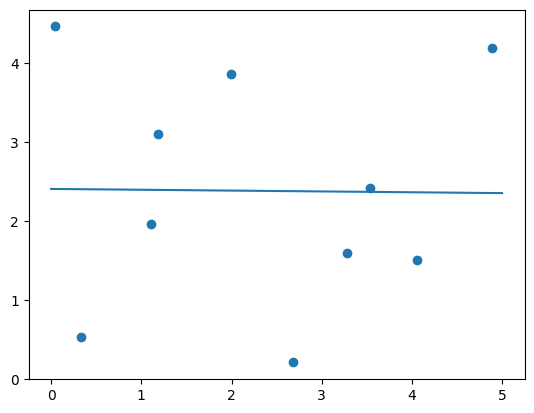

In [21]:
# with randomized vectors
import numpy as np

X = np.random.uniform(0, 5, 10)
X.sort()
Y = np.random.uniform(0, 5, 10)
# Solve using least squares

m, c = least_squares(X, Y)

print(f"Slope: {m}, Intercept: {c}")

plt.scatter(X, Y)
plt.plot(np.linspace(0, 5, 5), np.linspace(0, 5, 5)*m + c)
plt.show()


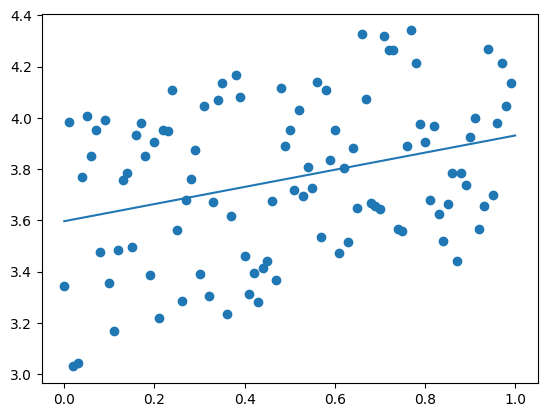

residuals=array([0.25258815, 0.38392494, 0.57339213, 0.56163132, 0.16059442,
       0.39386537, 0.23401353, 0.33377039, 0.14707257, 0.3627854 ,
       0.2766435 , 0.46428846, 0.1520088 , 0.11651623, 0.14253915,
       0.15012722, 0.28329193, 0.32726885, 0.1950627 , 0.27342396,
       0.24008308, 0.44784672, 0.27946287, 0.27344818, 0.43049459,
       0.11764182, 0.39756302, 0.00745452, 0.06978448, 0.17856954,
       0.30706144, 0.34598619, 0.3994855 , 0.03743488, 0.35888077,
       0.42119542, 0.48423339, 0.10612805, 0.44056482, 0.35229471,
       0.27027748, 0.42102486, 0.34523787, 0.46041635, 0.3321406 ,
       0.30588601, 0.07831539, 0.38608638, 0.35865242, 0.12875359,
       0.18763618, 0.05224023, 0.25740929, 0.08018905, 0.02880922,
       0.05803778, 0.3529766 , 0.25576322, 0.31608149, 0.03869629,
       0.15300495, 0.33080708, 0.00107555, 0.2951113 , 0.07004714,
       0.16861684, 0.5080964 , 0.24997829, 0.15723619, 0.17439615,
       0.18957995, 0.4816164 , 0.42580128, 0.4208453

In [25]:
# with random perturbation

M, B = 0.5, 3

X_b = np.arange(0, 1, 0.01)
Y_b = X_b*M + (np.random.uniform(0, 1, 100)+3)

m2, c2 = least_squares(X_b, Y_b)

X_actual, Y_actual = np.linspace(0, 1, 100), np.linspace(0, 1, 100)*m2 + c2

plt.scatter(X_b, Y_b)
plt.plot(X_actual, Y_actual)
plt.show()

residuals = np.abs(Y_actual - Y_b)
print(f"{residuals=}\n")
print(f"{max(residuals)=}, {min(residuals)=}")

0.3342150157473464, 3.5971589973167952; 0.3342150157473362, 3.5971589973168028


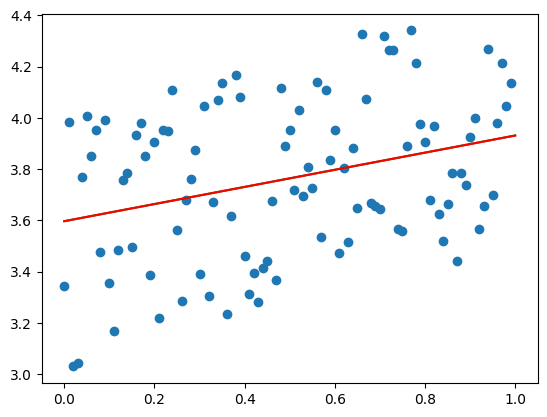

In [29]:
# compare against actual numpy

A = np.vstack([X_b, np.ones(len(X_b))]).T
m3, c3 = np.linalg.lstsq(A, Y_b, rcond=None)[0]

X_np, Y_np = np.linspace(0, 1, 100), np.linspace(0, 1, 100)*m3 + c3

print(f"{m2}, {c2}; {m3}, {c3}")

plt.scatter(X_b, Y_b)
plt.plot(X_actual, Y_actual, 'g')
plt.plot(X_np, Y_np, 'r')
plt.show()



In [ ]:
"""
Comparison:
The two functions return functionally the same result,
with only minor variation

"""